In [ ]:
# ▶️ STEP 1: Setup - Mount Drive, Import Libraries, Load & Save Data

import numpy as np
import json
import os
import pickle
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Mount drive
drive.mount('/content/drive')

np.random.seed(42)

FEATURES_DIR = "/content/drive/MyDrive/Feature Detection File for all subjects"
TIMESERIES_DIR = "/content/drive/MyDrive/Filtered EEG Files"
CLIP_EMB_PATH = "/content/drive/MyDrive/clip_embeddings_new_Old_Dataset.npy"

print("\n--- Loading Feature Files ---")

feature_json_paths = list(Path(FEATURES_DIR).rglob("*_processed_features.json"))

all_data = []
clean_data = []

for file_path in feature_json_paths:
    with open(file_path, 'r') as f:
        data = json.load(f)
        all_data.extend(data)

print("Total trials:", len(all_data))

for trial in all_data:
    if np.sum(np.abs(trial['features'][0])) > 1e-9:
        clean_data.append(trial)

print("Clean samples:", len(clean_data))

y_raw = np.array([trial['label'] for trial in clean_data])
X_raw = np.array([trial['features'] for trial in clean_data])

# -------- Feature scaling --------

num_samples, num_channels, num_features = X_raw.shape

X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)

scaler = StandardScaler()

X_scaled_features = scaler.fit_transform(X_reshaped)

# -------- Small Feature Noise --------

feature_noise = np.random.normal(0, 0.01, X_scaled_features.shape)
X_scaled_features = X_scaled_features + feature_noise

print("Feature shape:", X_scaled_features.shape)

# -------- Load EEG Timeseries --------

filtered_json_paths = list(Path(TIMESERIES_DIR).rglob("*_filtered_eeg.json"))

all_trials_data = []
all_trials_labels = []

for file_path in filtered_json_paths:

    with open(file_path, 'r') as f:

        data = json.load(f)

        for trial in data:

            all_trials_data.append(np.array(trial['eeg_data']))
            all_trials_labels.append(trial['label'])

X_timeseries = np.array(all_trials_data).transpose(0, 2, 1)

# -------- Small EEG Sensor Noise --------

ts_noise = np.random.normal(0, 0.005, X_timeseries.shape)
X_timeseries = X_timeseries + ts_noise

y_timeseries_str = np.array(all_trials_labels)

print("Timeseries shape:", X_timeseries.shape)

# -------- Load CLIP --------

clip_embeddings = np.load(CLIP_EMB_PATH, allow_pickle=True).item()

print("CLIP classes:", list(clip_embeddings.keys()))

# -------- Save dataset --------

data_to_save = {

'X_raw': X_raw,
'y_raw': y_raw,
'X_scaled_features': X_scaled_features,
'X_timeseries': X_timeseries,
'y_timeseries_str': y_timeseries_str,
'clip_embeddings': clip_embeddings

}

with open("all_data_new.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

print("Dataset saved → all_data_new.pkl")

Mounted at /content/drive

--- Loading Feature Files ---
Total trials: 2136
Clean samples: 2086
Feature shape: (2086, 40)
Timeseries shape: (2259, 375, 2)
CLIP classes: ['triangle', 'circle', 'square']
Dataset saved → all_data_new.pkl


In [ ]:
# === Load the dataset dictionary created from Step 1 ===
import pickle

with open("all_data_new.pkl", "rb") as f:
    data = pickle.load(f)

X_raw = data["X_raw"]                         # shape: (N, 2, 20)
y_raw = data["y_raw"]                         # labels (strings)
X_scaled_features = data["X_scaled_features"] # shape: (N, 40)
clip_embeddings = data["clip_embeddings"]     # dict: class → CLIP vector


In [ ]:
# === Build PyTorch Dataset for Feature-Based Models ===
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Convert label strings → integer classes
unique_labels = sorted(list(set(y_raw)))
label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
y_int = np.array([label_to_idx[l] for l in y_raw])

# Convert CLIP class dict → class embedding matrix
clip_matrix = np.stack([clip_embeddings[k] for k in unique_labels]).astype(np.float32)
clip_matrix = torch.tensor(clip_matrix)

class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

ds = FeatureDataset(X_scaled_features, y_int)

# Train/validation split
from sklearn.model_selection import train_test_split
idx_train, idx_val = train_test_split(np.arange(len(ds)), test_size=0.2, stratify=y_int, random_state=42)

train_ds = torch.utils.data.Subset(ds, idx_train)
val_ds   = torch.utils.data.Subset(ds, idx_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

print("Feature-based dataset ready!")
print("Train size:", len(train_ds), "Val size:", len(val_ds))


Feature-based dataset ready!
Train size: 1668 Val size: 418


# Tri-Fusion XG Boost Model

Device: cuda
Samples: (2086, 40)
Train: (1668, 40) Test: (418, 40)
Leaf columns: 64
Leaf categories: 16
Epoch 1  ValAcc=0.5957
✓ Best model saved
Epoch 2  ValAcc=0.6962
✓ Best model saved
Epoch 3  ValAcc=0.8349
✓ Best model saved
Epoch 4  ValAcc=0.8517
✓ Best model saved
Epoch 5  ValAcc=0.9139
✓ Best model saved
Epoch 6  ValAcc=0.9139
Epoch 7  ValAcc=0.9163
✓ Best model saved
Epoch 8  ValAcc=0.9282
✓ Best model saved
Epoch 9  ValAcc=0.9163
Epoch 10  ValAcc=0.9498
✓ Best model saved
Epoch 11  ValAcc=0.9641
✓ Best model saved
Epoch 12  ValAcc=0.9498
Epoch 13  ValAcc=0.9450
Epoch 14  ValAcc=0.9522
Epoch 15  ValAcc=0.9593
Epoch 16  ValAcc=0.9450
Epoch 17  ValAcc=0.9522
Epoch 18  ValAcc=0.9569
Epoch 19  ValAcc=0.9545
Epoch 20  ValAcc=0.9641
Epoch 21  ValAcc=0.9761
✓ Best model saved
Epoch 22  ValAcc=0.9713
Epoch 23  ValAcc=0.9713
Epoch 24  ValAcc=0.9713
Epoch 25  ValAcc=0.9713
Epoch 26  ValAcc=0.9737
Epoch 27  ValAcc=0.9713
Epoch 28  ValAcc=0.9689
Epoch 29  ValAcc=0.9737
Epoch 30  ValAcc=0.

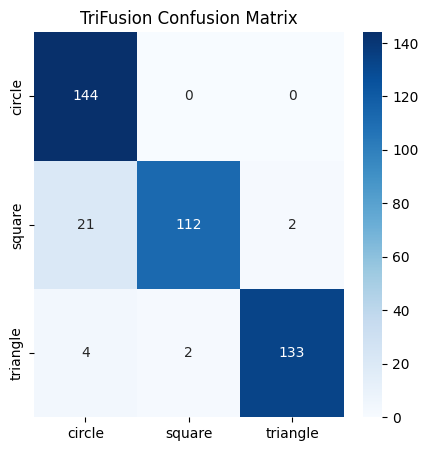

In [ ]:
# ============================================================
# TriFusion v3 (Stable Version)
# ============================================================

import numpy as np, pickle, random, torch, json
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- reproducibility ----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

with open("all_data_new.pkl","rb") as f:
    data = pickle.load(f)

X = data["X_scaled_features"]
y_raw = data["y_raw"]
clip_emb = data["clip_embeddings"]

labels = sorted(list(set(y_raw)))
label_to_idx = {lab:i for i,lab in enumerate(labels)}

y = np.array([label_to_idx[l] for l in y_raw])
num_classes = len(labels)

print("Samples:",X.shape)

# ------------------------------------------------------------
# CLIP embeddings
# ------------------------------------------------------------

CLIP_MATRIX = torch.stack([
    F.normalize(torch.tensor(clip_emb[label],dtype=torch.float32),dim=0)
    for label in labels
]).to(device)

# ------------------------------------------------------------
# Train / Test split
# ------------------------------------------------------------

X_tr,X_te,y_tr,y_te = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=SEED
)

print("Train:",X_tr.shape,"Test:",X_te.shape)

# ------------------------------------------------------------
# XGBoost model
# ------------------------------------------------------------

params = {
"objective":"multi:softprob",
"num_class":num_classes,
"eta":0.07,
"max_depth":4,
"subsample":0.9,
"colsample_bytree":0.9
}

dtrain = xgb.DMatrix(X_tr,label=y_tr)
dtest  = xgb.DMatrix(X_te,label=y_te)

bst = xgb.train(params,dtrain,num_boost_round=100)

# save xgboost model
bst.save_model("xgboost_trifusion.json")

train_leaf = bst.predict(dtrain,pred_leaf=True)
test_leaf  = bst.predict(dtest,pred_leaf=True)

n_trees = train_leaf.shape[1]

# limit number of trees used
max_trees = min(n_trees,64)

train_leaf = train_leaf[:,:max_trees]
test_leaf  = test_leaf[:,:max_trees]

n_cols = max_trees

print("Leaf columns:",n_cols)

# ------------------------------------------------------------
# Encode leaves
# ------------------------------------------------------------

enc = OrdinalEncoder()

enc.fit(np.vstack([train_leaf,test_leaf]))

leaf_tr = enc.transform(train_leaf).astype(int)
leaf_te = enc.transform(test_leaf).astype(int)

n_categories = int(np.max(leaf_tr)+1)

print("Leaf categories:",n_categories)

# ------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------

BATCH = 64

train_ds = TensorDataset(
torch.tensor(X_tr).float(),
torch.tensor(leaf_tr).long(),
torch.tensor(y_tr).long()
)

train_loader = DataLoader(train_ds,batch_size=BATCH,shuffle=True)

# ------------------------------------------------------------
# Class weights
# ------------------------------------------------------------

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_tr
)

class_weights_t = torch.tensor(class_weights,dtype=torch.float32).to(device)

ce_loss = nn.CrossEntropyLoss(weight=class_weights_t)

# ------------------------------------------------------------
# TriFusion Model
# ------------------------------------------------------------

class TriFusion(nn.Module):

    def __init__(self):

        super().__init__()

        embed_dim = 128

        # EEG encoder
        self.eeg = nn.Sequential(

            nn.Linear(40,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(256,embed_dim),
            nn.ReLU()
        )

        # Leaf embeddings
        self.leaf_emb = nn.ModuleList(
            [nn.Embedding(n_categories,16) for _ in range(n_cols)]
        )

        self.leaf_proj = nn.Sequential(

            nn.Linear(n_cols*16,256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        # CLIP projection
        self.clip_proj = nn.Linear(512,embed_dim,bias=False)

        # Fusion attention
        self.fusion = nn.MultiheadAttention(
            embed_dim,
            num_heads=4,
            batch_first=True
        )

        # Class prototypes
        self.proto = nn.Parameter(torch.randn(num_classes,embed_dim))

        self.scale = 18

    def forward(self,Xfeat,Xleaf,y,clip_targets):

        eeg_z = self.eeg(Xfeat)

        parts = [self.leaf_emb[i](Xleaf[:,i]) for i in range(Xleaf.shape[1])]

        leaf_cat = torch.cat(parts,dim=1)

        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)

        clip_sample = clip_proj[y]

        Z = torch.stack([eeg_z,leaf_z,clip_sample],dim=1)

        fused,_ = self.fusion(Z,Z,Z)

        fused = fused.mean(dim=1)

        logits = fused @ self.proto.T * self.scale

        return logits,fused


model = TriFusion().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=3e-4)

triplet = nn.TripletMarginLoss(margin=0.3)

CLIP_T = CLIP_MATRIX

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

EPOCHS = 40
best_acc = 0

for ep in range(EPOCHS):

    model.train()

    for xb,leafb,yb in train_loader:

        xb = xb.to(device)
        leafb = leafb.to(device)
        yb = yb.to(device)

        logits,z = model(xb,leafb,yb,CLIP_T)

        ce = ce_loss(logits,yb)

        with torch.no_grad():

            clip_proj = model.clip_proj(CLIP_T)

            clip_sample = clip_proj[yb]

        kd = F.mse_loss(
            F.normalize(z,dim=1),
            F.normalize(clip_sample,dim=1)
        )

        neg = z[torch.randperm(z.size(0))]

        tri = triplet(z,clip_sample,neg.detach())

        loss = ce + 0.4*kd + 0.1*tri

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        Xv = torch.tensor(X_te).float().to(device)
        leafv = torch.tensor(leaf_te).long().to(device)
        yv = torch.tensor(y_te).long().to(device)

        logits,_ = model(Xv,leafv,yv,CLIP_T)

        preds = logits.argmax(1).cpu().numpy()

    acc = accuracy_score(y_te,preds)

    print(f"Epoch {ep+1}  ValAcc={acc:.4f}")

    # Save BEST model
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(),"trifusion_best_model_97%.pth")
        print("✓ Best model saved")

print("\nBest Accuracy:",best_acc)

# ------------------------------------------------------------
# Save FINAL model (last epoch ~93%)
# ------------------------------------------------------------

torch.save(model.state_dict(),"trifusion_final_model_93%.pth")
print("✓ Final model saved")

# save labels
json.dump(labels,open("label_mapping.json","w"))

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

print("\nFINAL ACC:",accuracy_score(y_te,preds))

print(classification_report(y_te,preds,target_names=labels))

cm = confusion_matrix(y_te,preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt="d",
xticklabels=labels,yticklabels=labels,cmap="Blues")
plt.title("TriFusion Confusion Matrix")
plt.show()

# t-SNE For Tri-Fusion XG Boost Model

Loaded TriFusion v3 FINAL model
Dataset loaded: (2086, 40)
Leaf matrix shape: (2086, 64)
Model rebuilt successfully
Embedding shape: (2086, 128)


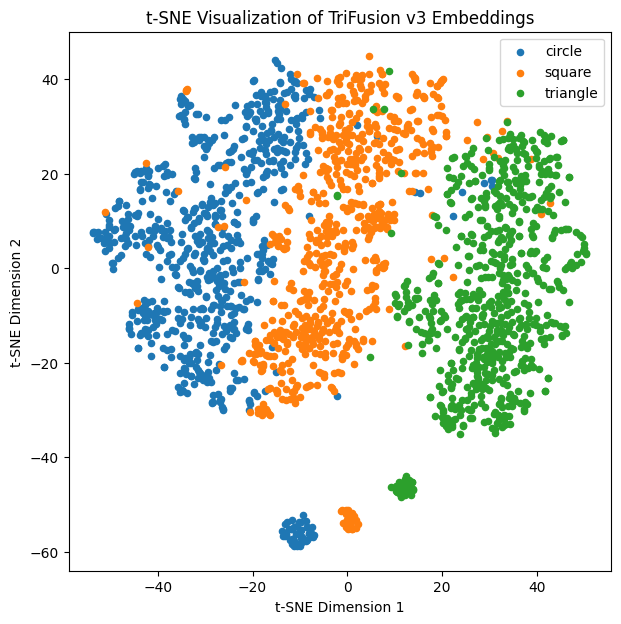

In [ ]:
# ============================================================
# t-SNE Visualization for TriFusion v3 FINAL MODEL (93%)
# ============================================================

import torch, pickle, numpy as np
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------------------
# 1. Load trained TriFusion v3 model
# ------------------------------------------------------------

state = torch.load("trifusion_final_model_93%.pth", map_location="cpu")

print("Loaded TriFusion v3 FINAL model")

# ------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------

with open("all_data_new.pkl","rb") as f:
    data = pickle.load(f)

X_all = data["X_scaled_features"]
y_raw = data["y_raw"]

labels = sorted(list(set(y_raw)))
y_all = np.array([labels.index(l) for l in y_raw])
num_classes = len(labels)

clip_matrix = torch.stack([
    torch.tensor(data["clip_embeddings"][lab]).float()
    for lab in labels
])

print("Dataset loaded:", X_all.shape)

# ------------------------------------------------------------
# 3. Train XGBoost again to obtain leaf indices
# (must match TriFusion training settings)
# ------------------------------------------------------------

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=42
)

params = {
"objective":"multi:softprob",
"num_class":num_classes,
"eta":0.07,
"max_depth":4,
"subsample":0.9,
"colsample_bytree":0.9
}

dtrain = xgb.DMatrix(X_tr,label=y_tr)
d_all  = xgb.DMatrix(X_all)

bst = xgb.train(params,dtrain,num_boost_round=100)

leaf_raw = bst.predict(d_all,pred_leaf=True)

# ------------------------------------------------------------
# 4. Encode leaf indices
# ------------------------------------------------------------

enc = OrdinalEncoder()
leaf_all = enc.fit_transform(leaf_raw).astype(int)

# limit to same number used in training
leaf_all = leaf_all[:,:64]

leaf_all_t = torch.tensor(leaf_all).long()

n_categories = int(np.max(leaf_all)+1)

print("Leaf matrix shape:",leaf_all.shape)

# ------------------------------------------------------------
# 5. Rebuild TriFusion v3 architecture
# ------------------------------------------------------------

class TriFusion(nn.Module):

    def __init__(self):

        super().__init__()

        embed_dim = 128

        self.eeg = nn.Sequential(

            nn.Linear(40,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(256,embed_dim),
            nn.ReLU()
        )

        self.leaf_emb = nn.ModuleList(
            [nn.Embedding(n_categories,16) for _ in range(64)]
        )

        self.leaf_proj = nn.Sequential(

            nn.Linear(64*16,256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.clip_proj = nn.Linear(512,embed_dim,bias=False)

        self.fusion = nn.MultiheadAttention(
            embed_dim,
            num_heads=4,
            batch_first=True
        )

        self.proto = nn.Parameter(torch.randn(num_classes,embed_dim))

        self.scale = 18

    def forward(self,Xfeat,Xleaf,y,clip_targets):

        eeg_z = self.eeg(Xfeat)

        parts = [self.leaf_emb[i](Xleaf[:,i]) for i in range(Xleaf.shape[1])]

        leaf_cat = torch.cat(parts,dim=1)

        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)

        clip_sample = clip_proj[y]

        Z = torch.stack([eeg_z,leaf_z,clip_sample],dim=1)

        fused,_ = self.fusion(Z,Z,Z)

        fused = fused.mean(dim=1)

        return fused


model = TriFusion()

model.load_state_dict(state)

model.eval()

print("Model rebuilt successfully")

# ------------------------------------------------------------
# 6. Extract fused embeddings
# ------------------------------------------------------------

X_all_t = torch.tensor(X_all).float()
y_all_t = torch.tensor(y_all).long()

with torch.no_grad():

    Z = model(X_all_t,leaf_all_t,y_all_t,clip_matrix)

Z_np = Z.numpy()

print("Embedding shape:",Z_np.shape)

# ------------------------------------------------------------
# 7. t-SNE projection
# ------------------------------------------------------------

ts = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

Z2 = ts.fit_transform(Z_np)

# ------------------------------------------------------------
# 8. Plot t-SNE
# ------------------------------------------------------------

plt.figure(figsize=(7,7))

for lab in labels:

    idx = np.where(np.array(y_raw)==lab)[0]

    plt.scatter(
        Z2[idx,0],
        Z2[idx,1],
        s=20,
        label=lab
    )

plt.legend()

plt.title("t-SNE Visualization of TriFusion v3 Embeddings")

plt.xlabel("t-SNE Dimension 1")

plt.ylabel("t-SNE Dimension 2")

plt.show()

# Metrics of Tri-Fusion XG Boost Model

Device: cuda
Samples: (2086, 40)

================ FINAL METRICS ================
Accuracy : 0.9474
Precision: 0.9519
Recall   : 0.9460
F1 Score : 0.9469


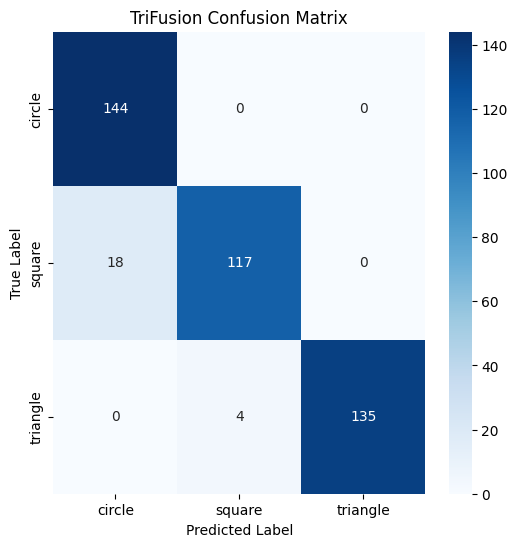

In [ ]:
# ============================================================
# TriFusion v3 Evaluation Script
# Computes Accuracy, Precision, Recall, F1 Score
# ============================================================

import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import xgboost as xgb
import json

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ============================================================
# Load dataset
# ============================================================

with open("all_data_new.pkl","rb") as f:
    data = pickle.load(f)

X = data["X_scaled_features"]
y_raw = data["y_raw"]
clip_emb = data["clip_embeddings"]

labels = sorted(list(set(y_raw)))
label_to_idx = {lab:i for i,lab in enumerate(labels)}

y = np.array([label_to_idx[l] for l in y_raw])
num_classes = len(labels)

print("Samples:",X.shape)

# ============================================================
# CLIP embeddings
# ============================================================

CLIP_MATRIX = torch.stack([
    F.normalize(torch.tensor(clip_emb[label],dtype=torch.float32),dim=0)
    for label in labels
]).to(device)

# ============================================================
# Train Test Split
# ============================================================

X_tr,X_te,y_tr,y_te = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

# ============================================================
# Load XGBoost model
# ============================================================

bst = xgb.Booster()
bst.load_model("xgboost_trifusion.json")

dtest = xgb.DMatrix(X_te)

test_leaf = bst.predict(dtest,pred_leaf=True)

max_trees = min(test_leaf.shape[1],64)

test_leaf = test_leaf[:,:max_trees]

n_cols = max_trees

# ============================================================
# Encode leaves
# ============================================================

enc = OrdinalEncoder()
enc.fit(test_leaf)

leaf_te = enc.transform(test_leaf).astype(int)

n_categories = int(np.max(leaf_te)+1)

# ============================================================
# TriFusion Model
# ============================================================

class TriFusion(nn.Module):

    def __init__(self):

        super().__init__()

        embed_dim = 128

        self.eeg = nn.Sequential(
            nn.Linear(40,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256,embed_dim),
            nn.ReLU()
        )

        self.leaf_emb = nn.ModuleList(
            [nn.Embedding(n_categories,16) for _ in range(n_cols)]
        )

        self.leaf_proj = nn.Sequential(
            nn.Linear(n_cols*16,256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.clip_proj = nn.Linear(512,embed_dim,bias=False)

        self.fusion = nn.MultiheadAttention(
            embed_dim,
            num_heads=4,
            batch_first=True
        )

        self.proto = nn.Parameter(torch.randn(num_classes,embed_dim))

        self.scale = 18

    def forward(self,Xfeat,Xleaf,y,clip_targets):

        eeg_z = self.eeg(Xfeat)

        parts = [self.leaf_emb[i](Xleaf[:,i]) for i in range(Xleaf.shape[1])]

        leaf_cat = torch.cat(parts,dim=1)

        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)

        clip_sample = clip_proj[y]

        Z = torch.stack([eeg_z,leaf_z,clip_sample],dim=1)

        fused,_ = self.fusion(Z,Z,Z)

        fused = fused.mean(dim=1)

        logits = fused @ self.proto.T * self.scale

        return logits

# ============================================================
# Load trained model
# ============================================================

model = TriFusion().to(device)

model.load_state_dict(torch.load("trifusion_final_model_93%.pth",map_location=device))

model.eval()

# ============================================================
# Prediction
# ============================================================

Xv = torch.tensor(X_te).float().to(device)
leafv = torch.tensor(leaf_te).long().to(device)
yv = torch.tensor(y_te).long().to(device)

with torch.no_grad():

    logits = model(Xv,leafv,yv,CLIP_MATRIX)

    preds = logits.argmax(1).cpu().numpy()

# ============================================================
# Metrics
# ============================================================

accuracy = accuracy_score(y_te,preds)

precision = precision_score(y_te,preds,average="macro")

recall = recall_score(y_te,preds,average="macro")

f1 = f1_score(y_te,preds,average="macro")

print("\n================ FINAL METRICS ================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_te,preds)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TriFusion Confusion Matrix")

plt.show()